# ARIMAX
Временная модель работает с одним рядом, поэтому агрегирую сессии по дням: таргет это дневная медиана, экзогенные признаки средняя длительность, среднее число событий и число сессий за день. Перебираю порядки (1,1,1) и (2,1,2), сезонность без неё и недельную, сравниваю с наивным прогнозом. Шкала ошибки дневная, с посессионными моделями напрямую не сравнивается.

In [1]:
import numpy as np
import pandas as pd
import time
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

datapath = "/kaggle/input/datasets/vikakolganova/crmses/sessions_crm.parquet"
seed = 42
maxrows = 90000
np.random.seed(seed)

data = pd.read_parquet(datapath)
for c in ["start", "end", "install_datetime", "prev_session_end", "session_date"]:
    if c in data.columns:
        data[c] = pd.to_datetime(data[c], errors="coerce")
print(data.shape)

(3071996, 85)


In [2]:
targets = ["target_next_session_length_sec", "future_sessions_mean_playtime_7d"]
labels = {"target_next_session_length_sec": "next_session", "future_sessions_mean_playtime_7d": "crm_7d"}

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def prodmae(yt, yp, cap=1200, tail=0.2, over=2.0, under=1.0):
    yt = np.asarray(yt, float)
    yp = np.asarray(yp, float)
    a = np.minimum(yt, cap)
    b = np.minimum(yp, cap)
    err = b - a
    w = np.where(yt > cap, tail, 1.0) * np.where(err > 0, over, under)
    return np.sum(w * np.abs(err)) / np.sum(w)

def engmae(yt, yp):
    yt = np.asarray(yt, float)
    yp = np.asarray(yp, float)
    ae = np.abs(yt - yp)
    w = np.select([yt <= 300, (yt > 300) & (yt <= 1200), yt > 1200], [1.0, 0.67, 0.05])
    return np.sum(w * ae) / np.sum(w)

def segmae(yt, yp, lo, hi):
    yt = np.asarray(yt, float)
    yp = np.asarray(yp, float)
    m = (yt > lo) & (yt <= hi)
    if m.any():
        return float(np.mean(np.abs(yt[m] - yp[m])))
    return np.nan

def score(yt, yp):
    yt = np.asarray(yt, float)
    yp = np.clip(np.asarray(yp, float), 0, None)
    ae = np.abs(yt - yp)
    return {"mae": mean_absolute_error(yt, yp),
            "rmse": mean_squared_error(yt, yp) ** 0.5,
            "medae": float(np.median(ae)),
            "r2": r2_score(yt, yp),
            "p70_abs_error": float(np.percentile(ae, 70)),
            "p90_abs_error": float(np.percentile(ae, 90)),
            "product_mae": prodmae(yt, yp),
            "engagement_risk_mae": engmae(yt, yp),
            "small_mae": segmae(yt, yp, -1, 300),
            "normal_mae": segmae(yt, yp, 300, 1200),
            "long_mae": segmae(yt, yp, 1200, 1e18)}

rows = []
preds = {}

def record(target, family, name, mode, loss, yval, valpred, ytest=None, testpred=None,
           params="", btmean=np.nan, btstd=np.nan, fitsec=0.0):
    row = {"target": target, "target_label": labels.get(target, target), "model_family": family,
           "model_name": name, "objective_tag": loss, "target_mode": mode, "loss_function": loss,
           "feature_set": "all", "params": params, "fit_sec": round(fitsec, 1), "status": "ok"}
    mv = score(yval, valpred)
    for k, v in mv.items():
        row["val_" + k] = v
    if testpred is not None:
        for k, v in score(ytest, testpred).items():
            row["test_" + k] = v
        preds[(target, name)] = (np.asarray(ytest, float), np.clip(np.asarray(testpred, float), 0, None))
    row["backtest_mae_mean"] = btmean
    row["backtest_mae_std"] = btstd
    rows.append(row)
    msg = labels.get(target, target) + "  " + name + "  val_mae=" + str(round(mv["mae"], 1)) + "  r2=" + str(round(mv["r2"], 2))
    if testpred is not None:
        msg += "  test_mae=" + str(round(row["test_mae"], 1))
    print(msg)

In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def daily(frame, target):
    d = frame.copy()
    d["day"] = d["start"].dt.normalize()
    t = d.groupby("day").agg(y=(target, "median"), dur=("duration_seconds", "mean"),
                             ev=("events_count", "mean"), cnt=("session_id", "count")).asfreq("D")
    return t.interpolate().ffill().bfill()

plots = {}
tries = []

def runarimax(target):
    full = daily(data, target)
    h = max(7, int(len(full) * 0.15))
    y = full["y"]
    ex = full[["dur", "ev", "cnt"]]
    ex = (ex - ex.mean()) / (ex.std() + 1e-9)
    ytr = y.iloc[:-h]
    yte = y.iloc[-h:]
    extr = ex.iloc[:-h]
    exte = ex.iloc[-h:]
    best = None
    for order in [(1, 1, 1), (2, 1, 2)]:
        for seas in [(0, 0, 0, 0), (1, 0, 1, 7)]:
            try:
                t0 = time.time()
                m = SARIMAX(ytr, exog=extr, order=order, seasonal_order=seas,
                            enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                f = m.get_forecast(steps=h, exog=exte).predicted_mean.values
                mae = np.mean(np.abs(yte.values - f))
                tries.append({"target": labels[target], "order": str(order), "seas": seas[-1], "mae": float(mae)})
                if best is None or mae < best[0]:
                    best = (mae, order, seas, f, time.time() - t0)
            except Exception:
                pass
    mae, order, seas, f, fitsec = best
    naive = np.repeat(ytr.iloc[-1], h)
    plots[target] = {"tridx": ytr.index, "tr": ytr.values, "teidx": yte.index, "te": yte.values,
                     "fc": np.asarray(f), "naive": np.asarray(naive), "order": order, "seas": seas[-1],
                     "mae": float(mae), "naivemae": float(np.mean(np.abs(yte.values - naive)))}
    print(labels[target], "ARIMAX", order, "seas", seas[-1],
          "mae", round(mae, 2), "naive", round(plots[target]["naivemae"], 2))
    record(target, "arimax", "arimax_" + str(order) + "_s" + str(seas[-1]), "median_daily", "MAE",
           yte.values, f, params=str(order), fitsec=fitsec)

for t in targets:
    runarimax(t)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


next_session ARIMAX (1, 1, 1) seas 0 mae 6.53 naive 12.9
next_session  arimax_(1, 1, 1)_s0  val_mae=6.5  r2=0.48


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


crm_7d ARIMAX (1, 1, 1) seas 0 mae 9.53 naive 9.87
crm_7d  arimax_(1, 1, 1)_s0  val_mae=9.5  r2=0.18


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Дневной ряд и прогноз

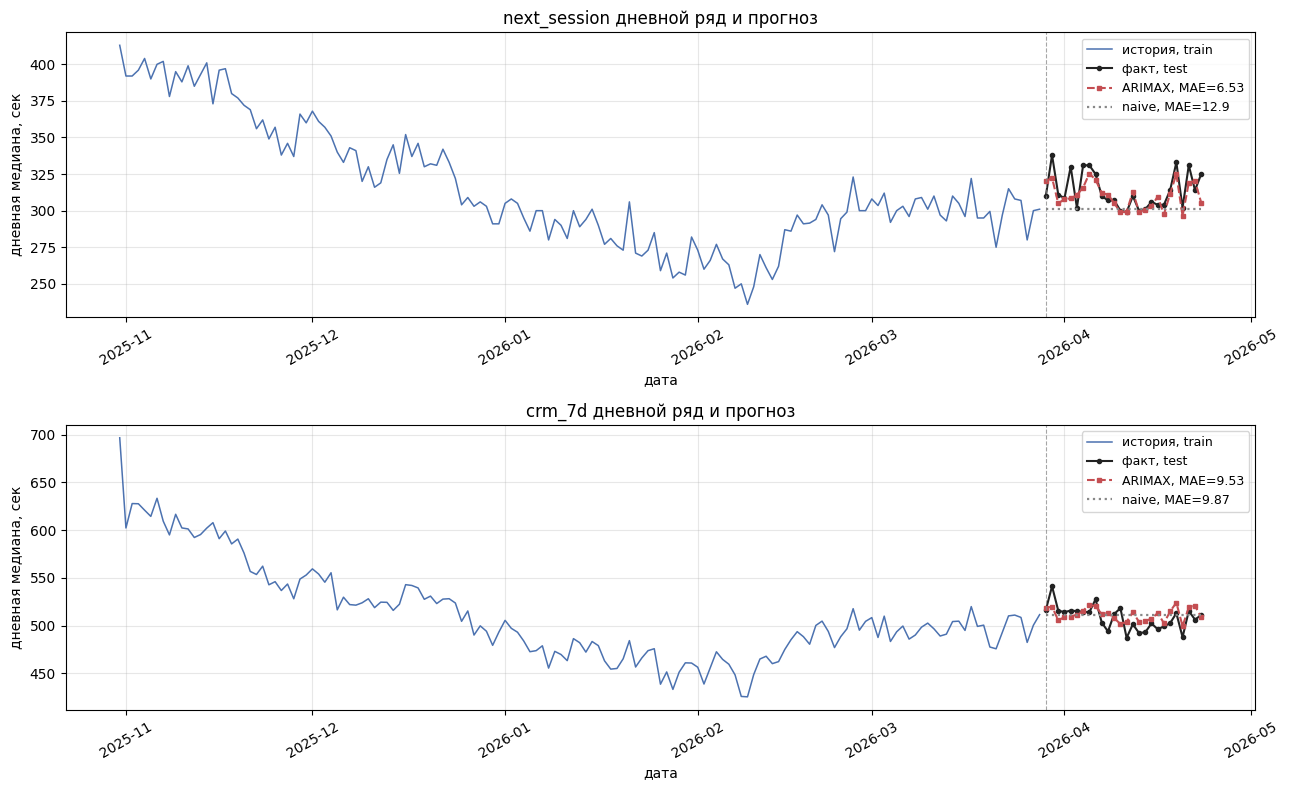

In [5]:
fig, axes = plt.subplots(len(targets), 1, figsize=(13, 4.0 * len(targets)))
for ax, t in zip(axes, targets):
    d = plots[t]
    ax.plot(d["tridx"], d["tr"], color="#4c72b0", lw=1.1, label="история, train")
    ax.plot(d["teidx"], d["te"], "o-", color="#222222", ms=3, label="факт, test")
    ax.plot(d["teidx"], d["fc"], "s--", color="#c44e52", ms=3, label="ARIMAX, MAE=" + str(round(d["mae"], 2)))
    ax.plot(d["teidx"], d["naive"], ":", color="#888888", lw=1.6, label="naive, MAE=" + str(round(d["naivemae"], 2)))
    ax.axvline(d["teidx"][0], color="gray", ls="--", lw=0.8, alpha=0.7)
    ax.set_title(labels[t] + " дневной ряд и прогноз")
    ax.set_xlabel("дата")
    ax.set_ylabel("дневная медиана, сек")
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Недельная агрегация

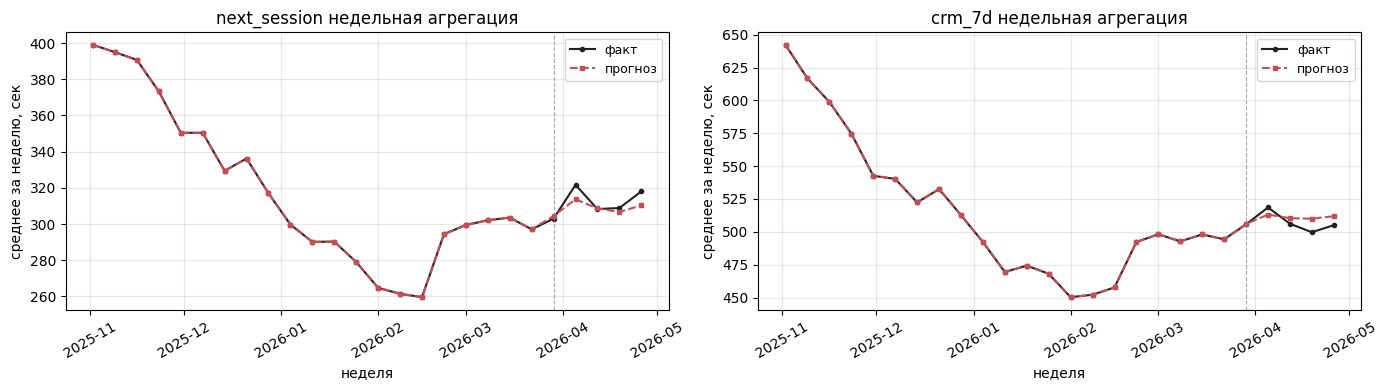

In [6]:
fig, axes = plt.subplots(1, len(targets), figsize=(7 * len(targets), 4.0))
for ax, t in zip(axes, targets):
    d = plots[t]
    fullidx = d["tridx"].append(d["teidx"])
    act = pd.Series(np.concatenate([d["tr"], d["te"]]), index=fullidx).resample("W").mean()
    fc = pd.Series(np.concatenate([d["tr"], d["fc"]]), index=fullidx).resample("W").mean()
    ax.plot(act.index, act.values, "o-", color="#222222", ms=3, label="факт")
    ax.plot(fc.index, fc.values, "s--", color="#c44e52", ms=3, label="прогноз")
    ax.axvline(d["teidx"][0], color="gray", ls="--", lw=0.8, alpha=0.7)
    ax.set_title(labels[t] + " недельная агрегация")
    ax.set_xlabel("неделя")
    ax.set_ylabel("среднее за неделю, сек")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Все перебранные варианты

In [7]:
display(pd.DataFrame(tries).sort_values(["target", "mae"]).round(2))

,target,order,seas,mae
4,crm_7d,"(1, 1, 1)",0,9.53
7,crm_7d,"(2, 1, 2)",7,9.56
6,crm_7d,"(2, 1, 2)",0,9.60
5,crm_7d,"(1, 1, 1)",7,9.81
0,next_session,"(1, 1, 1)",0,6.53
2,next_session,"(2, 1, 2)",0,6.59
1,next_session,"(1, 1, 1)",7,6.82
3,next_session,"(2, 1, 2)",7,7.05


## ACF и PACF

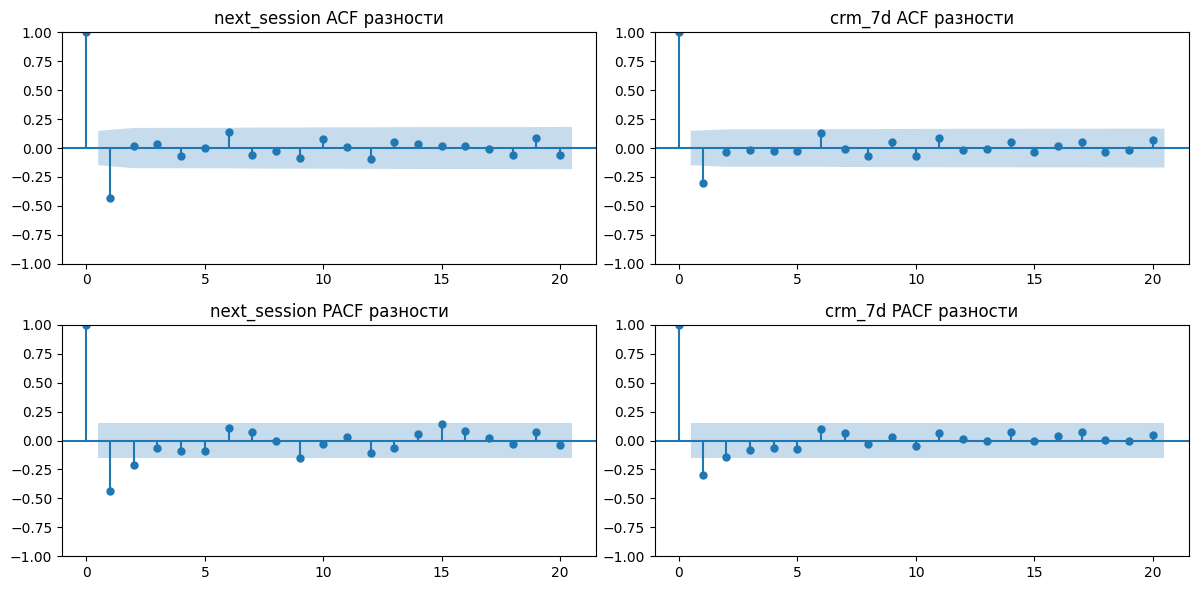

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for j, t in enumerate(targets):
    y = daily(data, t)["y"]
    plot_acf(y.diff().dropna(), ax=axes[0][j], lags=20, title=labels[t] + " ACF разности")
    plot_pacf(y.diff().dropna(), ax=axes[1][j], lags=20, title=labels[t] + " PACF разности")
plt.tight_layout()
plt.show()

## Остатки прогноза

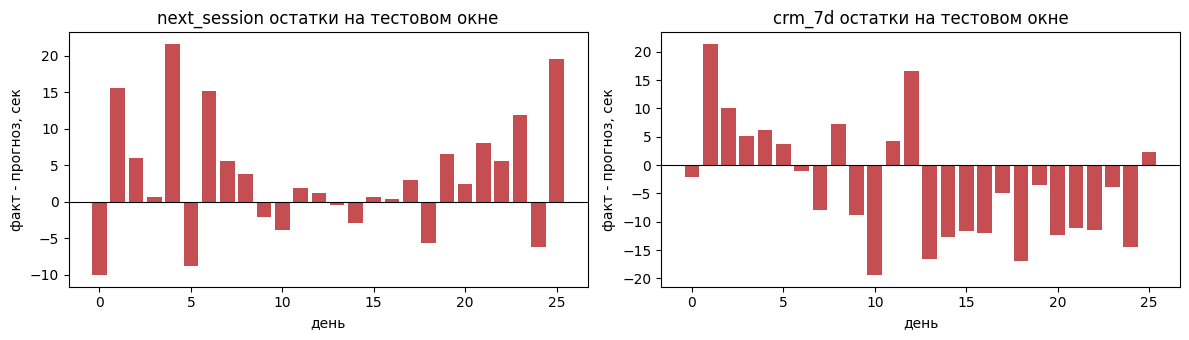

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, t in zip(axes, targets):
    d = plots[t]
    ax.bar(range(len(d["te"])), d["te"] - d["fc"], color="#c44e52")
    ax.axhline(0, color="k", lw=0.8)
    ax.set_title(labels[t] + " остатки на тестовом окне")
    ax.set_xlabel("день")
    ax.set_ylabel("факт - прогноз, сек")
plt.tight_layout()
plt.show()

In [10]:
for t in targets:
    full = daily(data, t)
    print(labels[t], " дней:", len(full), " медиана y:", round(full["y"].median(), 1),
          " std y:", round(full["y"].std(), 1))

next_session  дней: 175  медиана y: 306.0  std y: 38.7
crm_7d  дней: 175  медиана y: 502.5  std y: 46.3


In [11]:
pd.DataFrame(rows).to_csv("arimaxres.csv", index=False)